# Report 1: Fan & Deep Dive

**Target:** Appassionati, Otaku, Community Manager.
**Obiettivo:** Esplorare l'anima dell'industria, andando oltre i semplici numeri per capire cosa rende un anime "cult".

In questo notebook analizzeremo quattro pilastri della cultura anime:
1.  **La Vera Classifica (Weighted Rating):** Perché la media aritmetica sbaglia e qual è l'algoritmo per scoprire i veri capolavori.
2.  **I Colossi (Cast Analysis):** Come le serie più lunghe gestiscono centinaia di personaggi mantenendo il focus narrativo.
3.  **Le Icone (Top Staff):** Chi sono i doppiatori e i creatori che lavorano instancabilmente dietro le quinte?
4.  **Il Passaparola (Social Proof):** Analisi delle raccomandazioni per scoprire quali sono i titoli più influenti nella community, indipendentemente dal voto.

---
*Nota Tecnica: I dati sono caricati dalla cache ottimizzata (`.pkl`) generata nella pipeline di pulizia, integrati con i dataset grezzi per le analisi specifiche.*

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

sns.set_theme(style="whitegrid")
warnings.simplefilter(action='ignore', category=FutureWarning)

CACHE_PATH = '../cache/'
DATA_PATH = '../datasets/'

def load_dataset(pkl_name, csv_name, rename_map=None):
    """
    Carica il dataset dalla cache se esiste, altrimenti dal CSV originale.
    Applica rinominazioni base se caricato dal CSV per compatibilità.
    """
    pkl_file = os.path.join(CACHE_PATH, pkl_name)
    csv_file = os.path.join(DATA_PATH, csv_name)
    

    if os.path.exists(pkl_file):
        print(f"Caricato da CACHE: {pkl_name}")
        return pd.read_pickle(pkl_file)

    elif os.path.exists(csv_file):
        print(f"Cache assente. Caricamento da CSV GREZZO: {csv_name}")
        df = pd.read_csv(csv_file)
        
        if rename_map:
            df = df.rename(columns=rename_map)
            
        return df

    else:
        print(f"ERRORE CRITICO: Né {pkl_name} né {csv_name} trovati.")
        return None

print("--- INIZIO CARICAMENTO ---")

df_anime = load_dataset('anime.pkl', 'details.csv', {'mal_id': 'anime_id'})

df_chars = load_dataset('chars.pkl', 'characters.csv', {'character_mal_id': 'character_id'})

path_people_works_pkl = os.path.join(CACHE_PATH, 'people_works.pkl')

if os.path.exists(path_people_works_pkl):
    print(f"Caricato da CACHE: people_works.pkl")
    df_people_works = pd.read_pickle(path_people_works_pkl)
else:
    print("Cache People assente. Ricostruzione LIVE da CSV...")
    try:
        df_p_details = pd.read_csv(os.path.join(DATA_PATH, 'person_details.csv'))
        df_p_works = pd.read_csv(os.path.join(DATA_PATH, 'person_anime_works.csv'))

        df_people_works = pd.merge(
            df_p_works, 
            df_p_details[['person_mal_id', 'name']], 
            left_on='person_mal_id', 
            right_on='person_mal_id', 
            how='left'
        )
        df_people_works.rename(columns={'person_mal_id': 'person_id', 'anime_mal_id': 'anime_id'}, inplace=True)
        print("   -> Merge completato con successo.")
    except FileNotFoundError:
        print("Impossibile ricostruire People Works: mancano i CSV sorgente.")
        df_people_works = pd.DataFrame()

if df_anime is not None:
    print(f"\nStato Sistema: PRONTO. {len(df_anime)} anime caricati.")
    if isinstance(df_anime['genres'].iloc[0], str) and 'genre_list' not in df_anime.columns:
         df_anime['genre_list'] = df_anime['genres'].fillna('').astype(str).str.split(', ')
else:
    print("\nATTENZIONE: Il dataset principale (Anime) non è stato caricato.")

--- INIZIO CARICAMENTO ---
Caricato da CACHE: anime.pkl
Caricato da CACHE: chars.pkl
Caricato da CACHE: people_works.pkl

Stato Sistema: PRONTO. 28955 anime caricati.


--- ANALISI DEMOGRAFICA FAN ---
Caricato da CACHE: profiles.pkl


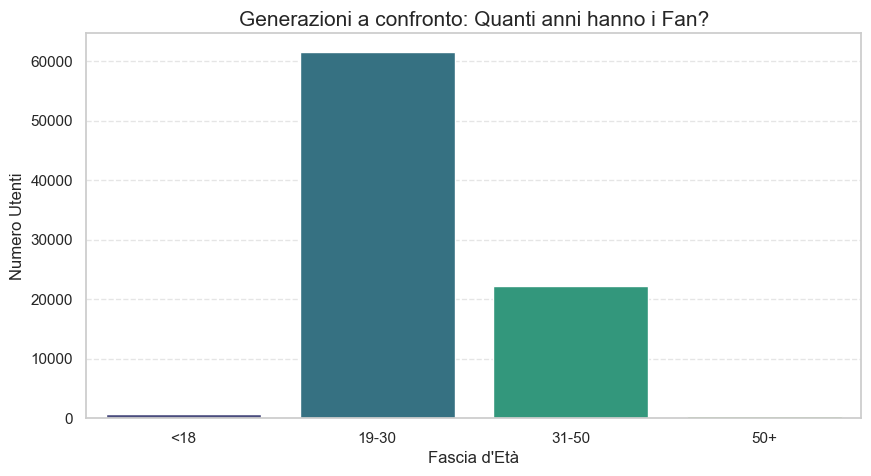

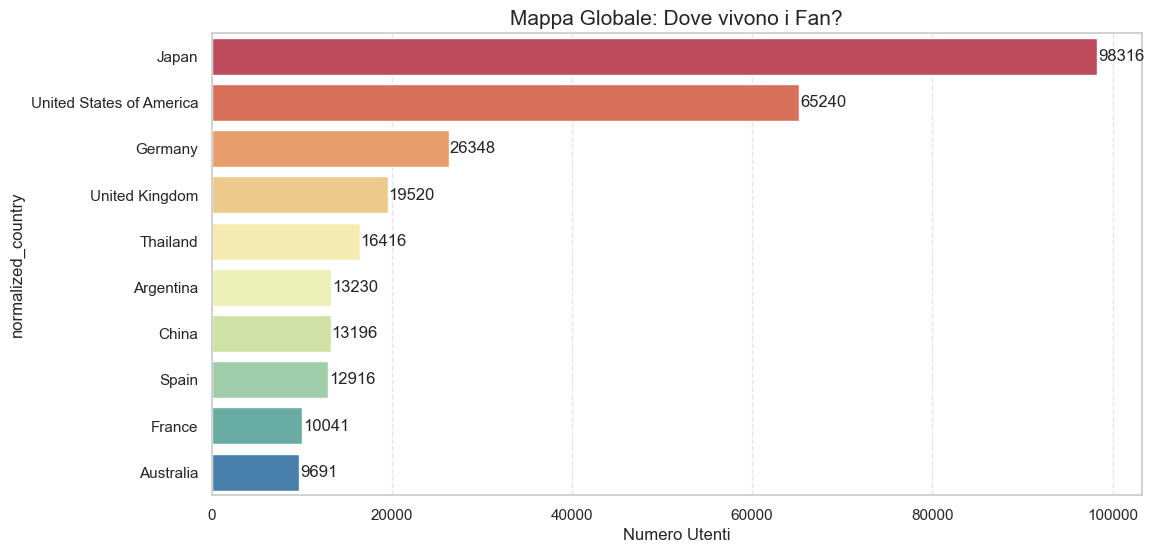

Generazione Word Cloud dei Generi...


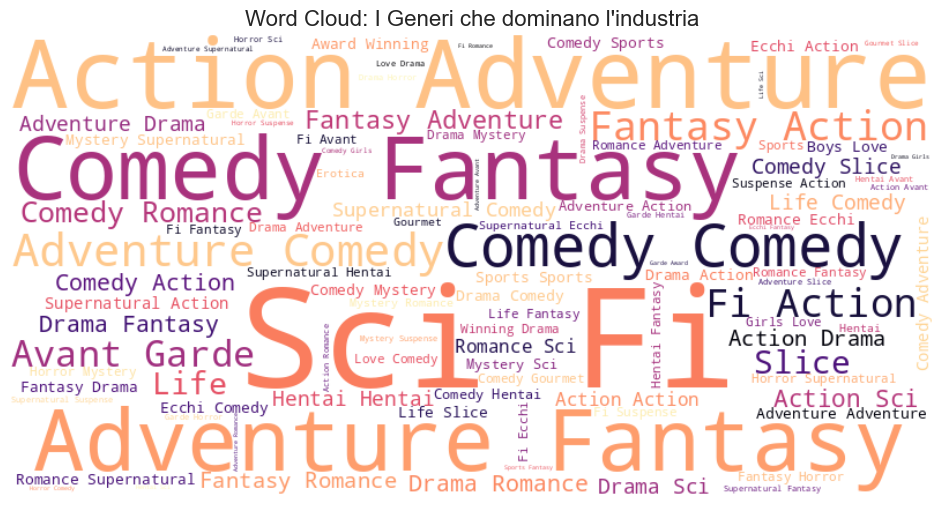

In [8]:
# --- SEZIONE: CHI SONO I FAN? (Demografica & Interessi) ---

from wordcloud import WordCloud

print("--- ANALISI DEMOGRAFICA FAN ---")

df_profiles = load_dataset('profiles.pkl', 'profiles.csv')

if df_profiles is not None:
    
    if 'age_group' in df_profiles.columns:
        plt.figure(figsize=(10, 5))
        order = ['<18', '19-30', '31-50', '50+']
        
        sns.countplot(
            data=df_profiles, 
            x='age_group', 
            order=order, 
            palette='viridis'
        )
        
        plt.title("Generazioni a confronto: Quanti anni hanno i Fan?", fontsize=15)
        plt.xlabel("Fascia d'Età")
        plt.ylabel("Numero Utenti")
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.show()
    else:
        print("Colonna 'age_group' non trovata. Verifica di aver eseguito il Data Cleaning aggiornato.")

    if 'normalized_country' in df_profiles.columns:
        top_countries = df_profiles['normalized_country'].value_counts().head(10)
        
        plt.figure(figsize=(12, 6))
        sns.barplot(
            x=top_countries.values, 
            y=top_countries.index, 
            palette='Spectral'
        )
        
        plt.title("Mappa Globale: Dove vivono i Fan?", fontsize=15)
        plt.xlabel("Numero Utenti")
        plt.grid(axis='x', linestyle='--', alpha=0.5)
        for i, v in enumerate(top_countries.values):
            plt.text(v + 100, i, str(v), va='center')
        plt.show()
    else:
        print("Colonna 'normalized_country' non trovata. Verifica il Cleaning.")

    print("Generazione Word Cloud dei Generi...")
    
    if 'genre_list' in df_anime.columns:
        all_genres = []
        df_anime['genre_list'].dropna().apply(lambda x: all_genres.extend(x) if isinstance(x, list) else None)

        text = ' '.join(all_genres)

        wordcloud = WordCloud(
            width=800, 
            height=400, 
            background_color='white', 
            colormap='magma',
            max_words=100
        ).generate(text)
        
        plt.figure(figsize=(12, 6))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title("Word Cloud: I Generi che dominano l'industria", fontsize=16)
        plt.show()

else:
    print("ERRORE: File profiles.pkl non trovato in cache.")

## 1. La "Vera" Classifica: Weighted Rating

La classifica basata sulla media semplice (`score`) è spesso ingannevole: un anime di nicchia visto da 5 persone che votano "10" finirebbe sopra a un capolavoro visto da un milione di utenti.

Per ottenere una classifica onesta, utilizziamo la formula del **Weighted Rating (WR)** (standard del settore, usata anche da IMDB):

$$WR = \frac{v}{v+m} \cdot R + \frac{m}{v+m} \cdot C$$

Dove:
* **R** = Voto medio dell'anime.
* **v** = Numero di voti ricevuti.
* **m** = Minimo voti richiesti (qui usiamo il top 15% di popolarità per filtrare il rumore).
* **C** = Voto medio globale di tutto il database.

> **Risultato atteso:** Questa metrica penalizza gli anime con pochi voti e premia la qualità che resiste alla prova del grande pubblico.

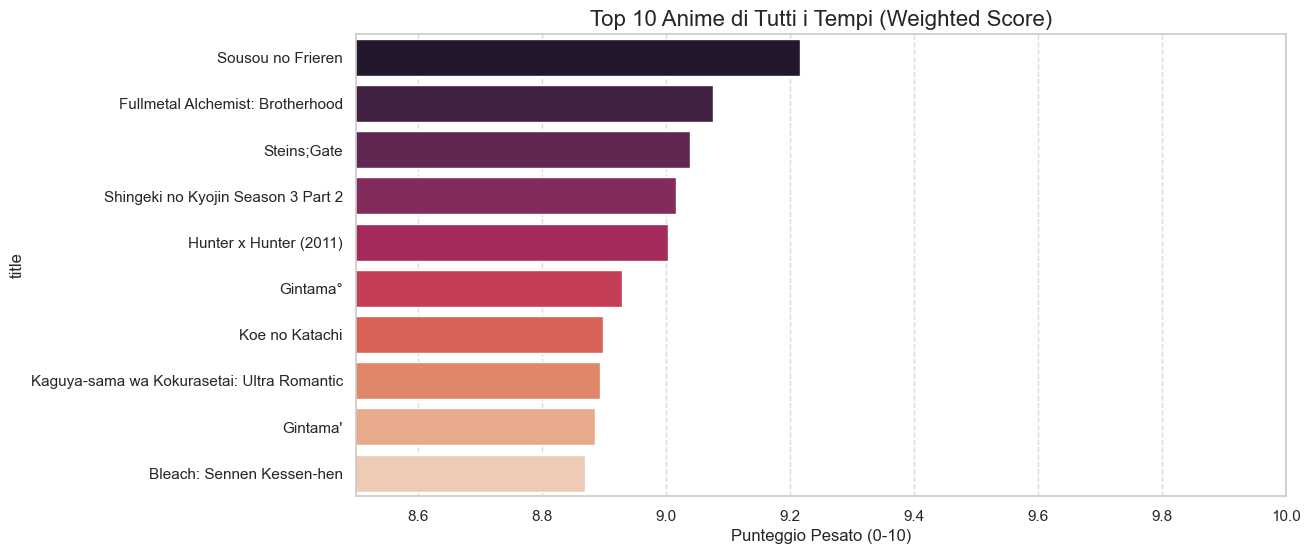

Top 3 Anime:


,title,weighted_score,score
23116,Sousou no Frieren,9.216017,9.29
6593,Fullmetal Alchemist: Brotherhood,9.075945,9.10
23288,Steins;Gate,9.039000,9.07


In [9]:
# --- ANALISI 1: TOP RATED (WEIGHTED SCORE) ---

C = df_anime['score'].mean()
m = df_anime['members'].quantile(0.85)

def weighted_rating(x, m=m, C=C):
    v = x['members']
    R = x['score']
    return (v/(v+m) * R) + (m/(v+m) * C)

q_anime = df_anime.copy().loc[df_anime['members'] >= m]
q_anime['weighted_score'] = q_anime.apply(weighted_rating, axis=1)

top_10 = q_anime.sort_values('weighted_score', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10, x='weighted_score', y='title', palette='rocket')
plt.title("Top 10 Anime di Tutti i Tempi (Weighted Score)", fontsize=16)
plt.xlabel("Punteggio Pesato (0-10)")
plt.xlim(8.5, 10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Top 3 Anime:")
display(top_10[['title', 'weighted_score', 'score']].head(3))

## 2. Analisi dei Colossi: La Struttura del Cast

Alcuni anime come *One Piece* o *Naruto* sono famosi per i loro mondi infiniti. Ma quanti personaggi sono davvero importanti per la storia?

In questo grafico sovrapposto confrontiamo:
* **Barra Chiara (Totale):** Il numero complessivo di personaggi accreditati (comparse incluse).
* **Barra Scura (Main):** Il numero di protagonisti reali (*Main Characters*).

**Insight:** Questo visualizza la "densità narrativa". Noteremo che anche nelle opere più vaste, il nucleo emotivo rimane sorprendentemente piccolo, permettendo allo spettatore di non perdersi nonostante la vastità del mondo.

Caricamento relazioni Personaggi-Anime...
Chiavi identificate -> Anime: 'anime_id', Characters: 'anime_mal_id'


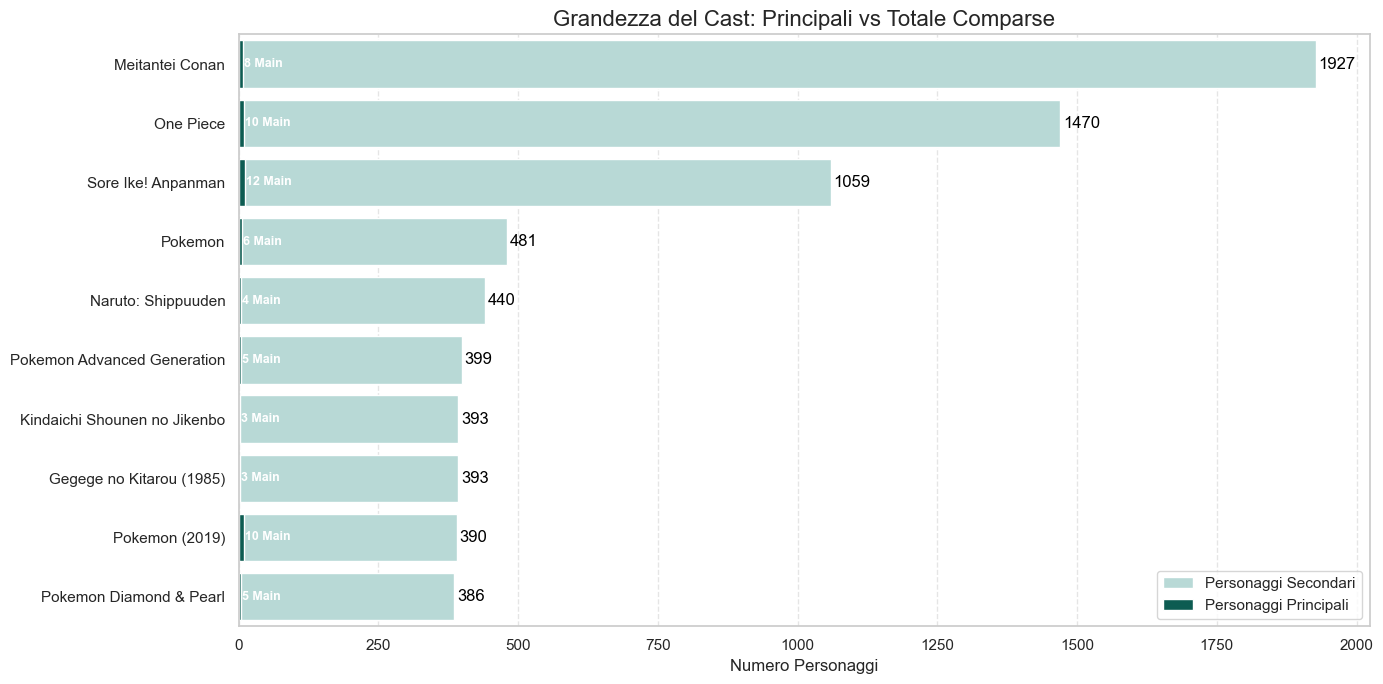

In [10]:
# --- ANALISI 2: Totale vs Main Characters (Bar Plot Sovrapposto) ---

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

print("Caricamento relazioni Personaggi-Anime...")
try:
    df_chars_works = pd.read_csv('../datasets/character_anime_works.csv')
except FileNotFoundError:
    print("Errore: Il file '../datasets/character_anime_works.csv' non esiste.")
    df_chars_works = None

if df_chars_works is not None and 'df_anime' in locals():

    anime_key_details = 'anime_id' 

    if 'anime_mal_id' in df_chars_works.columns:
        anime_key_chars = 'anime_mal_id'
    elif 'anime_id' in df_chars_works.columns:
        anime_key_chars = 'anime_id'
    else:
        anime_key_chars = df_chars_works.columns[1]
    
    print(f"Chiavi identificate -> Anime: '{anime_key_details}', Characters: '{anime_key_chars}'")

    total_counts = df_chars_works.groupby(anime_key_chars).size().reset_index(name='total_count')

    main_counts = df_chars_works[df_chars_works['role'] == 'Main'].groupby(anime_key_chars).size().reset_index(name='main_count')

    comparison_df = pd.merge(df_anime, total_counts, left_on=anime_key_details, right_on=anime_key_chars, how='inner')
    comparison_df = pd.merge(comparison_df, main_counts, on=anime_key_chars, how='left')

    comparison_df['main_count'] = comparison_df['main_count'].fillna(0)

    top_10_crowded = comparison_df.sort_values(by='total_count', ascending=False).head(10)

    plt.figure(figsize=(14, 7))

    sns.barplot(data=top_10_crowded, x='total_count', y='title', 
                label='Personaggi Secondari', color='#b2dfdb')

    sns.barplot(data=top_10_crowded, x='main_count', y='title', 
                label='Personaggi Principali', color='#00695c')

    plt.title('Grandezza del Cast: Principali vs Totale Comparse', fontsize=16)
    plt.xlabel('Numero Personaggi')
    plt.ylabel('')
    plt.legend(loc='lower right')
    plt.grid(axis='x', linestyle='--', alpha=0.5)

    for index, row in enumerate(top_10_crowded.itertuples()):
        plt.text(row.total_count + 5, index, f"{int(row.total_count)}", va='center', color='black')
        if row.main_count > 0:
            plt.text(row.main_count + 2, index, f"{int(row.main_count)} Main", 
                     va='center', color='white', fontweight='bold', fontsize=9)

    plt.tight_layout()
    plt.show()
    
else:
    print("Impossibile procedere: mancano i dati (df_anime) o il file CSV characters.")

## 3. Le Icone dell'Industria: Stakanovisti del Settore

Spesso i fan seguono un anime non per la trama, ma per il loro doppiatore (*Seiyuu*) preferito o per un regista specifico.

Analizzando il dataset `Person_Anime_Works`, stiliamo la classifica delle 10 persone con il maggior numero di ruoli accreditati nella storia.
Questa classifica rivela i "lavoratori instancabili" dell'industria giapponese, figure capaci di dare voce a centinaia di personaggi diversi nel corso della carriera.

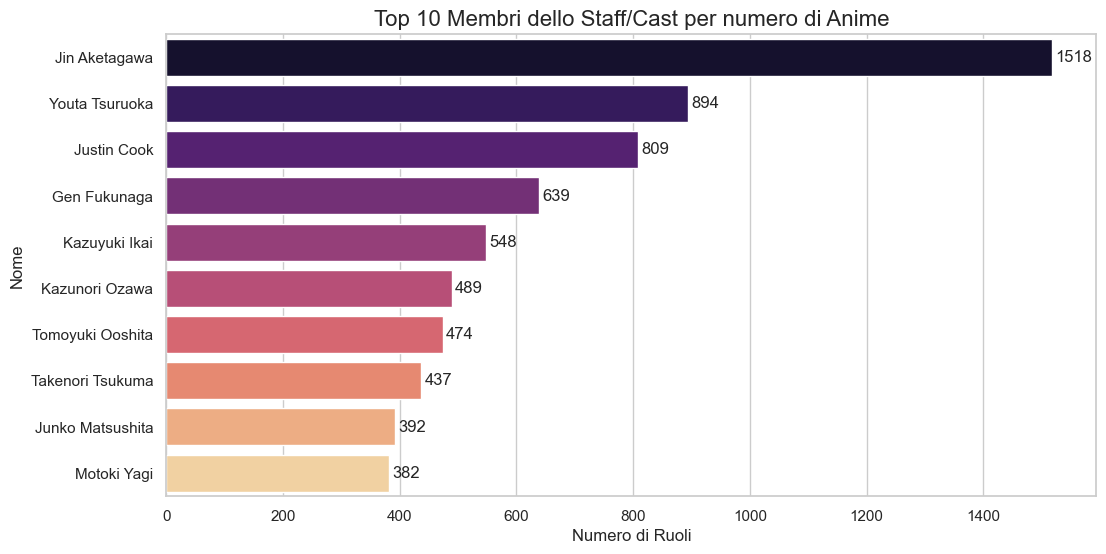

In [11]:
# --- ANALISI 3: TOP STAFF (VOICE ACTORS & STAFF) ---

if 'df_people_works' in locals() and df_people_works is not None:
    
    if 'name' in df_people_works.columns:
        top_staff = df_people_works['name'].value_counts().head(10)

        plt.figure(figsize=(12, 6))
        sns.barplot(x=top_staff.values, y=top_staff.index, palette='magma')

        plt.title("Top 10 Membri dello Staff/Cast per numero di Anime", fontsize=16)
        plt.xlabel("Numero di Ruoli")
        plt.ylabel("Nome")

        for i, v in enumerate(top_staff.values):
            plt.text(v + 5, i, str(v), va='center')

        plt.show()
    else:
        print("Errore: La colonna 'name' non esiste in df_people_works.")
else:
    print("Errore: Il dataset 'df_people_works' non è stato caricato. Controlla la Cella 1.")

## 4. Social Proof: I "Gateway Anime" più Consigliati

Oltre al voto, esiste un altro indicatore di successo: il **Passaparola**.
Il dataset `Recommendations.csv` traccia i suggerimenti degli utenti (es. *"Se ti piace A, devi guardare B"*).

Qui analizziamo quali sono gli anime che compaiono più spesso come suggerimento.
Essere molto raccomandati non significa necessariamente avere il voto più alto, ma significa essere un punto di riferimento culturale, un titolo che tutti citano come esempio del proprio genere.

Caricato da CACHE AGGREGATA: rec_stats_clean.pkl


/Users/manu/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


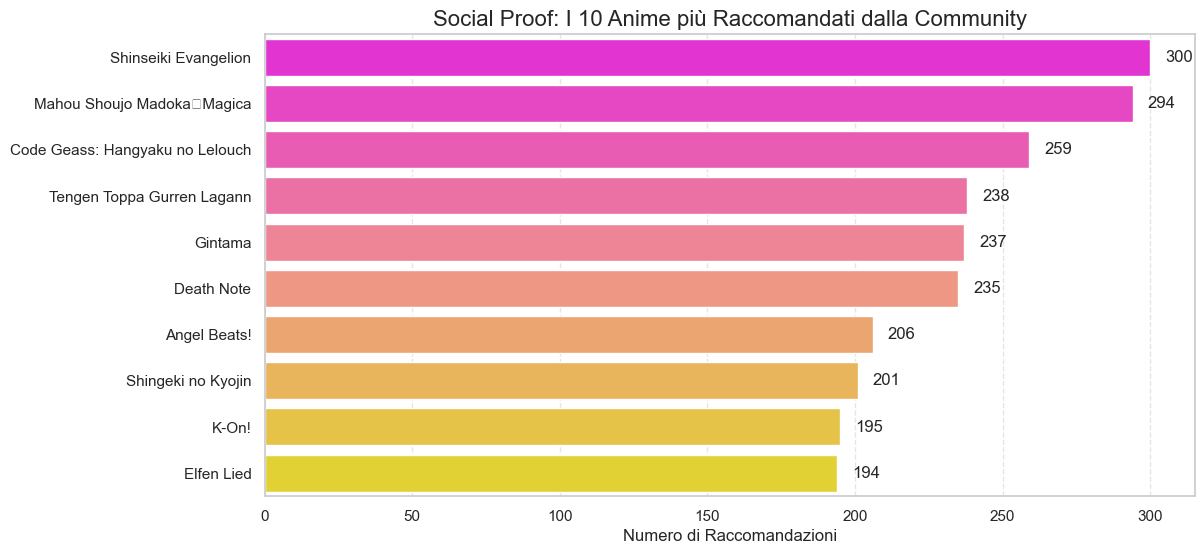

In [12]:
# --- ANALISI 4: I PIÙ CONSIGLIATI (RECOMMENDATIONS) ---

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

rec_cache_path = '../cache/rec_stats_clean.pkl'
rec_csv_path = '../datasets/Recommendations.csv'

df_top_recs = None

if os.path.exists(rec_cache_path):
    print(f"Caricato da CACHE AGGREGATA: rec_stats_clean.pkl")
    df_top_recs = pd.read_pickle(rec_cache_path)
    
elif os.path.exists(rec_csv_path):
    print(f"Cache assente. Elaborazione da CSV GREZZO: {rec_csv_path}")
    df_raw = pd.read_csv(rec_csv_path)
    target_col = df_raw.columns[1]
    df_top_recs = df_raw[target_col].value_counts().reset_index()
    df_top_recs.columns = ['anime_id', 'rec_count']

if df_top_recs is not None:
    if 'df_anime' in locals() and df_anime is not None:
        anime_key = 'anime_id' if 'anime_id' in df_anime.columns else 'mal_id'

        top_plot = df_top_recs.head(15).merge(
            df_anime[[anime_key, 'title']], 
            left_on='anime_id', 
            right_on=anime_key, 
            how='inner'
        )
        
        plt.figure(figsize=(12, 6))
        sns.barplot(
            data=top_plot.head(10),
            x='rec_count',
            y='title',
            palette='spring' 
        )

        plt.title('Social Proof: I 10 Anime più Raccomandati dalla Community', fontsize=16)
        plt.xlabel('Numero di Raccomandazioni')
        plt.ylabel('')
        plt.grid(axis='x', linestyle='--', alpha=0.5)

        for index, row in enumerate(top_plot.head(10).itertuples()):
            plt.text(row.rec_count + 5, index, f"{int(row.rec_count)}", va='center')

        plt.show()
        
    else:
        print("Errore: 'df_anime' non trovato. Impossibile associare i titoli agli ID.")
else:
    print("Errore: Dati raccomandazioni non trovati.")

### 🧠 Insight: Il Paradosso "Qualità vs Influenza"

Confrontando il grafico dei **Top Rated** (Cella 2) con quello dei **Top Recommended** (qui sopra), emerge un dato affascinante: **i due gruppi non coincidono.**

* **I "Capolavori" (Top Rated):** Classifiche dominate da titoli come *Fullmetal Alchemist: Brotherhood* o stagioni avanzate di *Gintama*. Questi rappresentano l'eccellenza qualitativa secondo i fan più devoti.
* **I "Gateway" (Top Recommended):** Classifiche dominate da titoli come *Death Note*, *Attack on Titan* o *Sword Art Online*. Questi rappresentano i **punti di ingresso** nell'industria.

**Conclusione:** Un numero alto di raccomandazioni non indica necessariamente che un anime sia "migliore" in assoluto, ma che è **più centrale** nella cultura pop. È più probabile che un utente consigli *Death Note* (per la sua trama avvincente e universale) piuttosto che un capolavoro di nicchia, creando così una discrepanza tra *Voto* e *Passaparola*.

## 📝 Conclusioni: Il Paradosso "Qualità vs Influenza"

Mettendo insieme le quattro analisi, emerge un quadro affascinante per il Fan esperto:

1.  **L'Eccellenza è Stabile:** I "Top Rated" (Weighted) sono titoli maturi e spesso lunghi (*Gintama*, *Fullmetal Alchemist*), che mantengono l'eccellenza su centinaia di episodi.
2.  **Il Paradosso del Consigliato:** C'è una discrepanza tra i **Voti** e le **Raccomandazioni**.
    * I titoli più votati sono i "Capolavori" (per intenditori).
    * I titoli più raccomandati (es. *Death Note*, *Attack on Titan*) sono i "Gateway Anime": opere accessibili e virali che servono a introdurre nuovi fan nel medium.
3.  **Il Fattore Umano:** L'industria si regge su poche, instancabili icone (Seiyuu) e su strutture narrative che, anche nei mondi più vasti, proteggono un nucleo ristretto di protagonisti.

---
*Analisi generata via Python/Pandas - Progetto HCI 2025*